# Magnetotelluric Impedance and Tipper Playground

This notebook loads complex spectra from windowed FFT outputs and computes simple least-squares estimates of the MT impedance tensor and tipper at each frequency.

In [102]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [103]:
!rm -rf spectra_output_complex
!python3 segment_fft_ascii.py --segments 5 --dt 2.0 --output-dir spectra_output_complex

Processed bxnT.ascii: 5 segments, 86000 samples/segment, dropped 0 samples.
Processed bynT.ascii: 5 segments, 86000 samples/segment, dropped 0 samples.
Processed bznT.ascii: 5 segments, 86000 samples/segment, dropped 0 samples.
Processed exmuVm.ascii: 5 segments, 86000 samples/segment, dropped 0 samples.
Processed eymuVm.ascii: 5 segments, 86000 samples/segment, dropped 0 samples.
All outputs written to /Users/sgkang09/Downloads/processing ascii/spectra_output_complex


In [ ]:
# Folder created by segment_fft_ascii.py
spectra_root = Path('spectra_output_complex')

# Map MT channels to spectra folders.
# The magnetic files are measured as Bx, By, Bz in nT and converted to H internally.
channel_dirs = {
    'Ex': 'exmuVm',
    'Ey': 'eymuVm',
    'Hx': 'bxnT',
    'Hy': 'bynT',
    'Hz': 'bznT',
}

# Convert channel spectra to SI units before estimating transfer functions.
# Ex, Ey: microvolts/m -> volts/m
# Bx, By, Bz in nanotesla are converted to H in A/m using H = B / mu0.
channel_scale_to_si = {
    'Ex': 1.0e-6,
    'Ey': 1.0e-6,
    'Hx': 1.0e-9 / (4.0e-7 * np.pi),
    'Hy': 1.0e-9 / (4.0e-7 * np.pi),
    'Hz': 1.0e-9 / (4.0e-7 * np.pi),
}

# Minimum number of windows required to estimate transfer functions.
min_windows = 2

# Log-frequency band settings.
bands_per_decade = 20
min_bins_per_band = 2

# Optional frequency range for plotting.
fmin = None
fmax = None

In [105]:
def load_segment_csv(path: Path):
    data = np.genfromtxt(path, delimiter=',', names=True)
    freq = np.asarray(data['frequency_hz'], dtype=float)
    values = np.asarray(data['fft_real'], dtype=float) + 1j * np.asarray(data['fft_imag'], dtype=float)
    return freq, values

def load_channel_spectra(channel_name: str, folder_name: str, spectra_root: Path, scale_to_si: float = 1.0):
    folder = spectra_root / folder_name
    files = sorted(folder.glob('segment_*_spectrum.csv'))
    if not files:
        raise FileNotFoundError(f'No segment spectra found for {channel_name} in {folder}')

    freq_ref = None
    spectra = []
    for path in files:
        freq, values = load_segment_csv(path)
        if freq_ref is None:
            freq_ref = freq
        elif not np.allclose(freq_ref, freq):
            raise ValueError(f'Frequency mismatch in {path}')
        spectra.append(values * scale_to_si)

    return {
        'channel': channel_name,
        'folder': folder,
        'frequency_hz': freq_ref,
        'spectra': np.vstack(spectra),
        'n_windows': len(spectra),
        'scale_to_si': scale_to_si,
    }

def load_all_channels(channel_dirs, spectra_root: Path, channel_scale_to_si=None):
    if channel_scale_to_si is None:
        channel_scale_to_si = {}
    channels = {}
    for channel_name, folder_name in channel_dirs.items():
        scale_to_si = channel_scale_to_si.get(channel_name, 1.0)
        channels[channel_name] = load_channel_spectra(channel_name, folder_name, spectra_root, scale_to_si=scale_to_si)

    freq_ref = None
    n_windows_ref = None
    for channel_name, info in channels.items():
        if freq_ref is None:
            freq_ref = info['frequency_hz']
        elif not np.allclose(freq_ref, info['frequency_hz']):
            raise ValueError(f'Frequency grid mismatch for {channel_name}')

        if n_windows_ref is None:
            n_windows_ref = info['n_windows']
        elif n_windows_ref != info['n_windows']:
            raise ValueError(f'Window count mismatch for {channel_name}')

    return channels

MU0 = 4.0e-7 * np.pi

def impedance_to_rhoa_phase(z, freq):
    omega = 2.0 * np.pi * freq
    rhoa = np.full(z.shape, np.nan, dtype=float)
    phase_deg = np.full(z.shape, np.nan, dtype=float)
    positive = freq > 0
    rhoa[positive] = np.abs(z[positive]) ** 2 / (MU0 * omega[positive])
    phase_deg[positive] = np.degrees(np.angle(z[positive]))
    return rhoa, phase_deg

def make_log_frequency_bands(freq, bands_per_decade=6, min_freq=None, max_freq=None):
    positive = freq[freq > 0]
    if positive.size == 0:
        raise ValueError('Need positive frequencies to build logarithmic bands.')
    if min_freq is None:
        min_freq = positive.min()
    if max_freq is None:
        max_freq = positive.max()
    if min_freq <= 0 or max_freq <= 0 or min_freq >= max_freq:
        raise ValueError('Invalid min/max frequency for logarithmic bands.')
    log_min = np.log10(min_freq)
    log_max = np.log10(max_freq)
    n_bands = int(np.ceil((log_max - log_min) * bands_per_decade))
    edges = np.logspace(log_min, log_max, n_bands + 1)
    return edges

def average_cross_spectrum(a, b):
    return np.mean(a * np.conj(b))

def estimate_mt_transfer_functions(channels, min_windows=2, bands_per_decade=6, min_bins_per_band=2):
    required = ['Ex', 'Ey', 'Hx', 'Hy', 'Hz']
    missing = [name for name in required if name not in channels]
    if missing:
        raise ValueError(f'Missing required channels: {missing}')

    fft_freq = channels['Ex']['frequency_hz']
    n_windows = channels['Ex']['n_windows']
    if n_windows < min_windows:
        raise ValueError(f'Need at least {min_windows} windows; found {n_windows}')

    band_edges = make_log_frequency_bands(fft_freq, bands_per_decade=bands_per_decade)
    band_freq = []
    zxx = []
    zxy = []
    zyx = []
    zyy = []
    tx = []
    ty = []
    hh_condition = []
    n_bin_contributions = []
    n_unique_fft_bins = []
    ex_rms = []
    ey_rms = []
    hz_rms = []

    ex_spec = channels['Ex']['spectra']
    ey_spec = channels['Ey']['spectra']
    hx_spec = channels['Hx']['spectra']
    hy_spec = channels['Hy']['spectra']
    hz_spec = channels['Hz']['spectra']

    for low, high in zip(band_edges[:-1], band_edges[1:]):
        if high == band_edges[-1]:
            band_mask = (fft_freq >= low) & (fft_freq <= high)
        else:
            band_mask = (fft_freq >= low) & (fft_freq < high)

        if np.count_nonzero(band_mask) < min_bins_per_band:
            continue

        ex_band = ex_spec[:, band_mask].reshape(-1)
        ey_band = ey_spec[:, band_mask].reshape(-1)
        hx_band = hx_spec[:, band_mask].reshape(-1)
        hy_band = hy_spec[:, band_mask].reshape(-1)
        hz_band = hz_spec[:, band_mask].reshape(-1)

        s_hh = np.array([
            [average_cross_spectrum(hx_band, hx_band), average_cross_spectrum(hx_band, hy_band)],
            [average_cross_spectrum(hy_band, hx_band), average_cross_spectrum(hy_band, hy_band)],
        ], dtype=complex)
        s_eh = np.array([
            [average_cross_spectrum(ex_band, hx_band), average_cross_spectrum(ex_band, hy_band)],
            [average_cross_spectrum(ey_band, hx_band), average_cross_spectrum(ey_band, hy_band)],
        ], dtype=complex)
        s_zh = np.array([
            average_cross_spectrum(hz_band, hx_band), average_cross_spectrum(hz_band, hy_band)
        ], dtype=complex)

        inv_s_hh = np.linalg.inv(s_hh)
        z_band = s_eh @ inv_s_hh
        t_band = s_zh @ inv_s_hh

        band_freq.append(np.exp(np.mean(np.log(fft_freq[band_mask]))))
        zxx.append(z_band[0, 0])
        zxy.append(z_band[0, 1])
        zyx.append(z_band[1, 0])
        zyy.append(z_band[1, 1])
        tx.append(t_band[0])
        ty.append(t_band[1])
        hh_condition.append(np.linalg.cond(s_hh))
        n_unique_fft_bins.append(np.count_nonzero(band_mask))
        n_bin_contributions.append(ex_band.size)
        ex_rms.append(np.nan)
        ey_rms.append(np.nan)
        hz_rms.append(np.nan)

    freq = np.asarray(band_freq, dtype=float)
    zxx = np.asarray(zxx, dtype=complex)
    zxy = np.asarray(zxy, dtype=complex)
    zyx = np.asarray(zyx, dtype=complex)
    zyy = np.asarray(zyy, dtype=complex)
    tx = np.asarray(tx, dtype=complex)
    ty = np.asarray(ty, dtype=complex)
    hh_condition = np.asarray(hh_condition, dtype=float)
    n_unique_fft_bins = np.asarray(n_unique_fft_bins, dtype=int)
    n_bin_contributions = np.asarray(n_bin_contributions, dtype=int)
    ex_rms = np.asarray(ex_rms, dtype=float)
    ey_rms = np.asarray(ey_rms, dtype=float)
    hz_rms = np.asarray(hz_rms, dtype=float)

    rhoa_xx, phase_xx = impedance_to_rhoa_phase(zxx, freq)
    rhoa_xy, phase_xy = impedance_to_rhoa_phase(zxy, freq)
    rhoa_yx, phase_yx = impedance_to_rhoa_phase(zyx, freq)
    rhoa_yy, phase_yy = impedance_to_rhoa_phase(zyy, freq)
    period_s = np.divide(1.0, freq, out=np.full_like(freq, np.inf), where=freq > 0)

    return {
        'frequency_hz': freq,
        'period_s': period_s,
        'Zxx': zxx,
        'Zxy': zxy,
        'Zyx': zyx,
        'Zyy': zyy,
        'rhoa_xx_ohm_m': rhoa_xx,
        'rhoa_xy_ohm_m': rhoa_xy,
        'rhoa_yx_ohm_m': rhoa_yx,
        'rhoa_yy_ohm_m': rhoa_yy,
        'phase_xx_deg': phase_xx,
        'phase_xy_deg': phase_xy,
        'phase_yx_deg': phase_yx,
        'phase_yy_deg': phase_yy,
        'Tx': tx,
        'Ty': ty,
        'Ex_rms_misfit': ex_rms,
        'Ey_rms_misfit': ey_rms,
        'Hz_rms_misfit': hz_rms,
        'HH_condition_number': hh_condition,
        'n_unique_fft_bins': n_unique_fft_bins,
        'n_bin_contributions': n_bin_contributions,
        'bands_per_decade': bands_per_decade,
    }

def apply_frequency_mask(results, fmin=None, fmax=None):
    mask = np.ones(results['frequency_hz'].shape, dtype=bool)
    if fmin is not None:
        mask &= results['frequency_hz'] >= fmin
    if fmax is not None:
        mask &= results['frequency_hz'] <= fmax
    return {key: value[mask] if hasattr(value, '__len__') and np.shape(value) == np.shape(mask) else value for key, value in results.items()}

In [106]:
channels = load_all_channels(channel_dirs, spectra_root, channel_scale_to_si=channel_scale_to_si)
tf = estimate_mt_transfer_functions(
    channels,
    min_windows=min_windows,
    bands_per_decade=bands_per_decade,
    min_bins_per_band=min_bins_per_band,
)
tf_plot = apply_frequency_mask(tf, fmin=fmin, fmax=fmax)

print('Loaded channels:')
for name, info in channels.items():
    print(f"  {name}: {info['n_windows']} windows, {info['frequency_hz'].size} frequencies, scale_to_si={info['scale_to_si']}")
print(f'Banding: {bands_per_decade} bands/decade, minimum {min_bins_per_band} FFT bins per band')

for i in range(5):
    print(tf_plot['frequency_hz'][i], tf_plot['Zxy'][i], tf_plot['Tx'][i])

Loaded channels:
  Ex: 5 windows, 43001 frequencies, scale_to_si=1e-06
  Ey: 5 windows, 43001 frequencies, scale_to_si=1e-06
  Hx: 5 windows, 43001 frequencies, scale_to_si=0.0007957747154594768
  Hy: 5 windows, 43001 frequencies, scale_to_si=0.0007957747154594768
  Hz: 5 windows, 43001 frequencies, scale_to_si=0.0007957747154594768
Banding: 50 bands/decade, minimum 2 FFT bins per band
0.00014241219434785938 (0.0004934843918896143+0.0004282462042426413j) (-0.06847287696917945-0.029969388385087836j)
0.00017148699074130932 (0.0005001993538361906+0.0005318730064690321j) (-0.20042981569338247+0.029624291360414945j)
0.0001947457467958629 (0.0004384174122107656+0.0004835455399131211j) (-0.20735418714048987-0.14804583294576285j)
0.00020637487615463753 (0.0007091874157796066+0.00027440371424591046j) (-0.13735427067037614-0.053098274102830856j)
0.0002238183320339555 (0.0007586643575094745+0.0006338129489143491j) (-0.10479536987984532-0.07186871714992736j)


In [107]:
freq_index = 10
freq = tf['frequency_hz'][freq_index]
period = tf['period_s'][freq_index]

print(f'Frequency index: {freq_index}')
print(f'Frequency: {freq:.6e} Hz')
print(f'Period: {period:.6e} s')
print(f'FFT bins in band: {tf["n_unique_fft_bins"][freq_index]}')
print(f'Window-bin contributions: {tf["n_bin_contributions"][freq_index]}')
print(f'Zxx = {tf["Zxx"][freq_index]} ohm')
print(f'Zxy = {tf["Zxy"][freq_index]} ohm')
print(f'Zyx = {tf["Zyx"][freq_index]} ohm')
print(f'Zyy = {tf["Zyy"][freq_index]} ohm')
print(f'rhoa_xy = {tf["rhoa_xy_ohm_m"][freq_index]} ohm m')
print(f'phase_xy = {tf["phase_xy_deg"][freq_index]} deg')
print(f'rhoa_yx = {tf["rhoa_yx_ohm_m"][freq_index]} ohm m')
print(f'phase_yx = {tf["phase_yx_deg"][freq_index]} deg')
print(f'Tx  = {tf["Tx"][freq_index]}')
print(f'Ty  = {tf["Ty"][freq_index]}')

Frequency index: 10
Frequency: 2.964736e-04 Hz
Period: 3.372981e+03 s
FFT bins in band: 3
Window-bin contributions: 15
Zxx = (0.0006073381813409492+0.0005956470031526909j) ohm
Zxy = (0.0006085528821956451+0.000522151753237525j) ohm
Zyx = (0.0010882628271241688+0.0011475045859840644j) ohm
Zyy = (0.001055918188862483+0.0006586099997946693j) ohm
rhoa_xy = 274.67620505041356 ohm m
phase_xy = 40.630319109488916 deg
rhoa_yx = 1068.445239519041 ohm m
phase_yx = 46.51782724870362 deg
Tx  = (-0.16789348609607585+0.05369289890894857j)
Ty  = (0.17419417211600668+0.05580037269507607j)


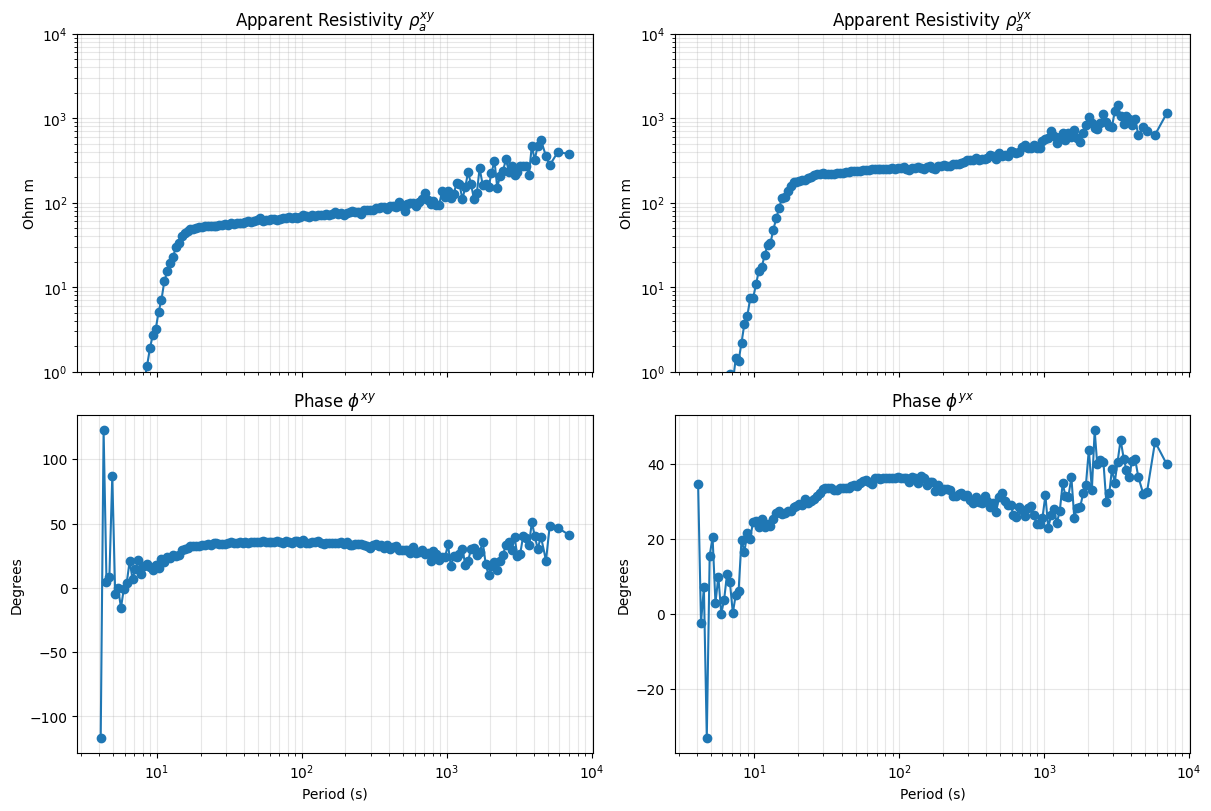

In [108]:
mask = tf_plot['frequency_hz'] > 0
period = tf_plot['period_s'][mask]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True, sharex=True)

components = [
    ('xy', 'rhoa_xy_ohm_m', 'phase_xy_deg', axes[0, 0], axes[1, 0]),
    ('yx', 'rhoa_yx_ohm_m', 'phase_yx_deg', axes[0, 1], axes[1, 1]),
]

for label, rho_key, phase_key, ax_rho, ax_phase in components:
    rho = tf_plot[rho_key][mask]
    phase = tf_plot[phase_key][mask]
    ax_rho.loglog(period, rho, 'o-', lw=1.5)
    ax_rho.set_title(f'Apparent Resistivity $\\rho_a^{{{label}}}$')
    ax_rho.set_ylabel('Ohm m')
    ax_rho.grid(True, which='both', alpha=0.3)
    ax_rho.invert_xaxis()
    ax_rho.set_ylim(1, 1e4)
    ax_phase.semilogx(period, phase, 'o-', lw=1.5)
    ax_phase.set_title(f'Phase $\\phi^{{{label}}}$')
    ax_phase.set_xlabel('Period (s)')
    ax_phase.set_ylabel('Degrees')
    ax_phase.grid(True, which='both', alpha=0.3)
    ax_phase.invert_xaxis()

plt.show()

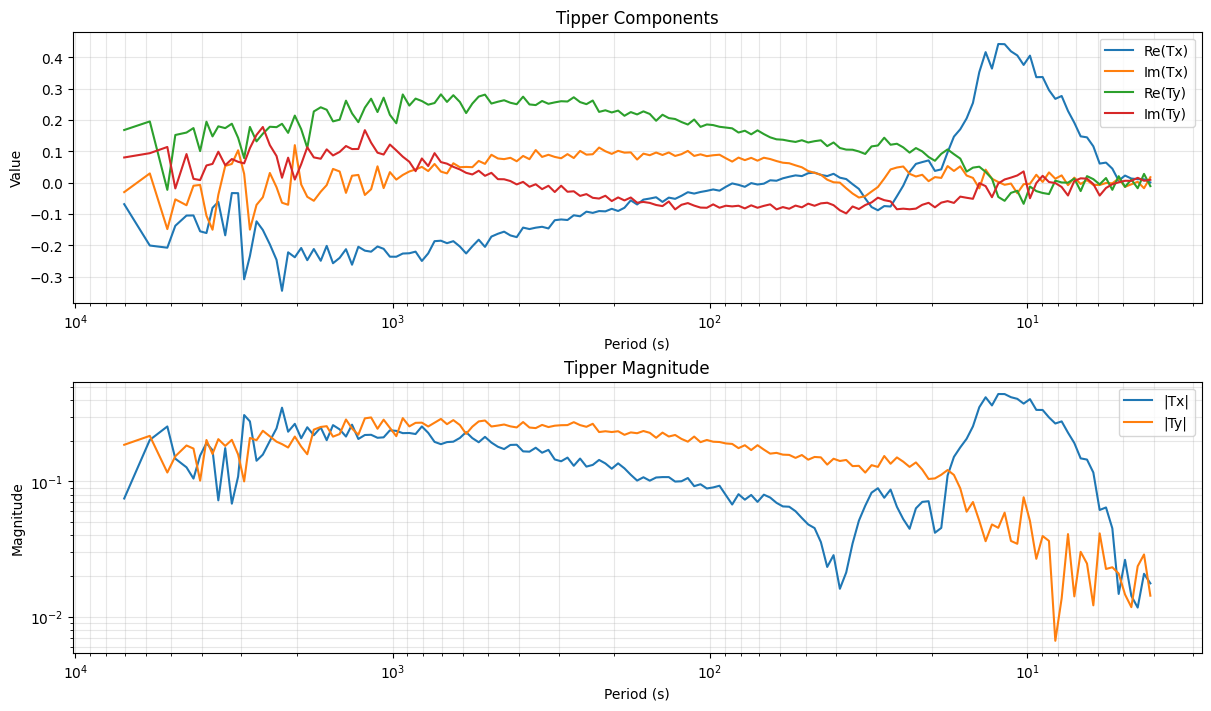

In [109]:
mask = tf_plot['frequency_hz'] > 0
period = tf_plot['period_s'][mask]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

axes[0].semilogx(period, np.real(tf_plot['Tx'][mask]), label='Re(Tx)')
axes[0].semilogx(period, np.imag(tf_plot['Tx'][mask]), label='Im(Tx)')
axes[0].semilogx(period, np.real(tf_plot['Ty'][mask]), label='Re(Ty)')
axes[0].semilogx(period, np.imag(tf_plot['Ty'][mask]), label='Im(Ty)')
axes[0].set_title('Tipper Components')
axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel('Value')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend()
axes[0].invert_xaxis()

axes[1].loglog(period, np.abs(tf_plot['Tx'][mask]), label='|Tx|')
axes[1].loglog(period, np.abs(tf_plot['Ty'][mask]), label='|Ty|')
axes[1].set_title('Tipper Magnitude')
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel('Magnitude')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend()
axes[1].invert_xaxis()

plt.show()

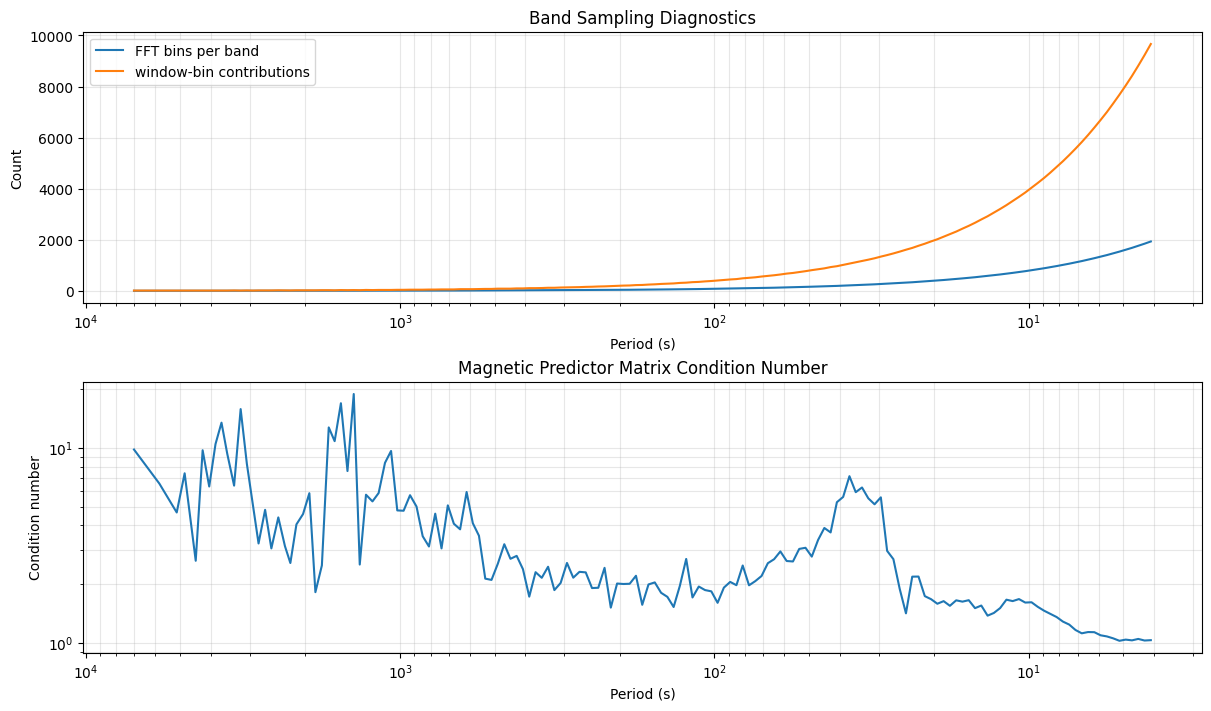

In [110]:
mask = tf_plot['frequency_hz'] > 0
period = tf_plot['period_s'][mask]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

axes[0].semilogx(period, tf_plot['n_unique_fft_bins'][mask], label='FFT bins per band')
axes[0].semilogx(period, tf_plot['n_bin_contributions'][mask], label='window-bin contributions')
axes[0].set_title('Band Sampling Diagnostics')
axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel('Count')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend()
axes[0].invert_xaxis()

axes[1].loglog(period, tf_plot['HH_condition_number'][mask])
axes[1].set_title('Magnetic Predictor Matrix Condition Number')
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel('Condition number')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].invert_xaxis()

plt.show()